# Pune Transit Monitor: Schedule Data Analysis

This notebook analyses the final cleaned PMPML GTFS static feed. It describes **published schedules**: planned trips, stop visits, and planned timetable gaps. It does not measure live vehicle locations, delay, cancellation, ridership, crowding, or on-time performance.

## Analysis workflow

The notebook reads the final CSV files from `data/cleaned`, checks data quality and relationships, then examines route activity, stop activity, route coverage, scheduled headways, time-of-day patterns, overnight service, and the geographic distribution of stops.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.float_format', '{:,.2f}'.format)

project_root = Path.cwd().parent if Path.cwd().name == 'eda' else Path.cwd()
cleaned_dir = project_root / 'data' / 'cleaned'

routes = pd.read_csv(cleaned_dir / 'routes_clean.csv')
stops = pd.read_csv(cleaned_dir / 'stops_clean.csv')
trips = pd.read_csv(cleaned_dir / 'trips_clean.csv')
stop_times = pd.read_csv(cleaned_dir / 'stop_times_clean.csv')
calendar = pd.read_csv(cleaned_dir / 'calendar_clean.csv')
analysis = pd.read_csv(cleaned_dir / 'transit_schedule_analysis_clean.csv')

tables = {
    'routes': routes, 'stops': stops, 'trips': trips, 'stop_times': stop_times,
    'calendar': calendar, 'transit_schedule_analysis': analysis,
}

## 1. Dataset overview

In [2]:
overview = pd.DataFrame([
    {'dataset': name, 'rows': len(table), 'columns': len(table.columns)}
    for name, table in tables.items()
])

print(f"Calendar validity: {calendar['start_date'].min()} to {calendar['end_date'].max()}")
overview

Calendar validity: 2026-08-06 to 2027-02-02


,dataset,rows,columns
0,routes,627,6
1,stops,6696,6
2,trips,15138,5
3,stop_times,627199,11
4,calendar,1,10
5,transit_schedule_analysis,627199,28


## 2. Data-quality and relationship checks

In [3]:
key_columns = {
    'routes': ['route_id'], 'stops': ['stop_id'], 'trips': ['trip_id'],
    'stop_times': ['trip_id', 'stop_sequence'], 'calendar': ['service_id'],
    'transit_schedule_analysis': ['trip_id', 'stop_sequence'],
}

quality_summary = pd.DataFrame([
    {
        'dataset': name,
        'missing_values': int(table.isna().sum().sum()),
        'duplicate_key_rows': int(table.duplicated(key_columns[name]).sum()),
        'required_key_nulls': int(table[key_columns[name]].isna().sum().sum()),
    }
    for name, table in tables.items()
])

relationship_checks = pd.DataFrame({
    'check': [
        'Trips with missing routes', 'Trips with missing service IDs',
        'Stop-time rows with missing trips', 'Stop-time rows with missing stops',
        'Analysis rows missing route IDs', 'Analysis rows missing stop names',
    ],
    'invalid_rows': [
        (~trips['route_id'].isin(routes['route_id'])).sum(),
        (~trips['service_id'].isin(calendar['service_id'])).sum(),
        (~stop_times['trip_id'].isin(trips['trip_id'])).sum(),
        (~stop_times['stop_id'].isin(stops['stop_id'])).sum(),
        analysis['route_id'].isna().sum(), analysis['stop_name'].isna().sum(),
    ],
})

display(quality_summary)
display(relationship_checks)

,dataset,missing_values,duplicate_key_rows,required_key_nulls
0,routes,1254,0,0
1,stops,13392,0,0
2,trips,0,0,0
3,stop_times,1881597,0,0
4,calendar,0,0,0
5,transit_schedule_analysis,4447069,0,0


,check,invalid_rows
0,Trips with missing routes,0
1,Trips with missing service IDs,0
2,Stop-time rows with missing trips,0
3,Stop-time rows with missing stops,0
4,Analysis rows missing route IDs,0
5,Analysis rows missing stop names,0


The remaining missing values are optional GTFS descriptive fields, such as route descriptions, stop descriptions, colours, and boarding attributes. Missing headways are expected for the first arrival in each route/direction/stop sequence.

## 3. Route activity

In [4]:
route_activity = (
    analysis.groupby(['route_id', 'route_short_name'], dropna=False)
    .agg(
        scheduled_trips=('trip_id', 'nunique'),
        scheduled_stop_visits=('stop_id', 'size'),
    )
    .reset_index()
    .sort_values('scheduled_stop_visits', ascending=False)
)
route_activity['route_label'] = (
    route_activity['route_short_name'].astype(str) + ' (ID ' + route_activity['route_id'].astype(str) + ')'
)
top_routes = route_activity.head(15)
display(top_routes[['route_id', 'route_short_name', 'scheduled_trips', 'scheduled_stop_visits']])

plt.figure(figsize=(11, 7))
sns.barplot(data=top_routes, x='scheduled_stop_visits', y='route_label', color='#2878b5')
plt.title('Top 15 route records by scheduled stop visits')
plt.xlabel('Scheduled stop visits')
plt.ylabel('Route number (GTFS route ID)')
plt.tight_layout()
plt.show()

,route_id,route_short_name,scheduled_trips,scheduled_stop_visits
96,178,149,80,6880
97,179,149,79,6873
117,222,159,81,5346
472,851,43,79,5135
116,221,159,72,4824
471,850,43,72,4392
562,1041,98,75,4275
561,1040,98,75,4125
317,587,309,87,4002
181,365,204,66,3960


<Figure size 1100x700 with 1 Axes>

**Interpretation:** Scheduled stop visits combine planned trips and the number of stops served. A route number can appear under more than one GTFS route ID, commonly representing directions or variants; do not combine them unless that meaning has been confirmed.

## 4. Stop activity

,stop_id,stop_name,routes_serving_stop,scheduled_stop_visits
2552,3315,Swargate,96,2519
86,107,Pune Station Moledina Stand,79,2101
103,130,St Colony,79,1893
104,131,Bhapkar Petrol Pump,76,1785
267,319,Income Tax Office,69,1814
999,1204,Gadital,60,1489
268,320,Gpo,59,1628
30,40,Shivaji Maharaj Putla,55,1589
269,321,Collector Kacheri,55,1316
355,419,Hadapsar Gadital,54,1748


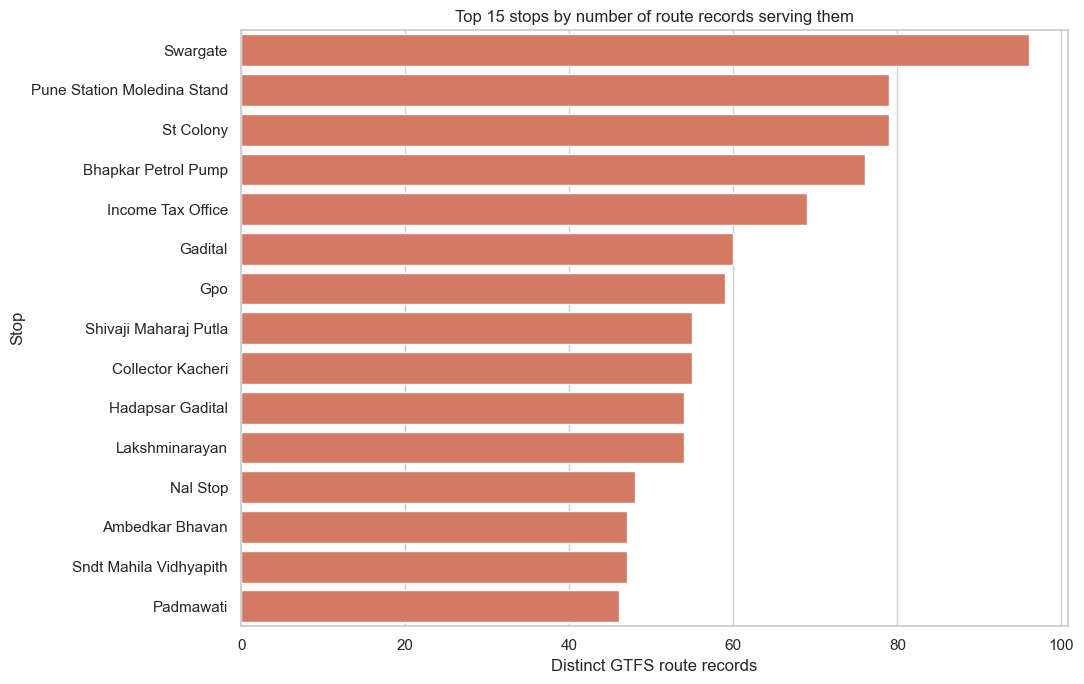

In [5]:
stop_activity = (
    analysis.groupby(['stop_id', 'stop_name'], dropna=False)
    .agg(
        routes_serving_stop=('route_id', 'nunique'),
        scheduled_stop_visits=('trip_id', 'size'),
    )
    .reset_index()
    .sort_values(['routes_serving_stop', 'scheduled_stop_visits'], ascending=False)
)
top_stops = stop_activity.head(15)
display(top_stops)

plt.figure(figsize=(11, 7))
sns.barplot(data=top_stops, x='routes_serving_stop', y='stop_name', color='#e76f51')
plt.title('Top 15 stops by number of route records serving them')
plt.xlabel('Distinct GTFS route records')
plt.ylabel('Stop')
plt.tight_layout()
plt.show()

**Interpretation:** Stops with many distinct route records are potential interchange locations. This measures scheduled network connectivity, not passenger footfall or transfer volume.

## 5. Route coverage

,route_id,route_short_name,unique_stops,scheduled_trips
222,449,231,118,2
221,448,231,117,2
199,400,213,114,13
200,401,213,114,13
60,124,135,106,1
61,125,135,105,2
64,130,137,105,5
197,396,212,104,3
198,397,212,104,3
276,533,296,104,11


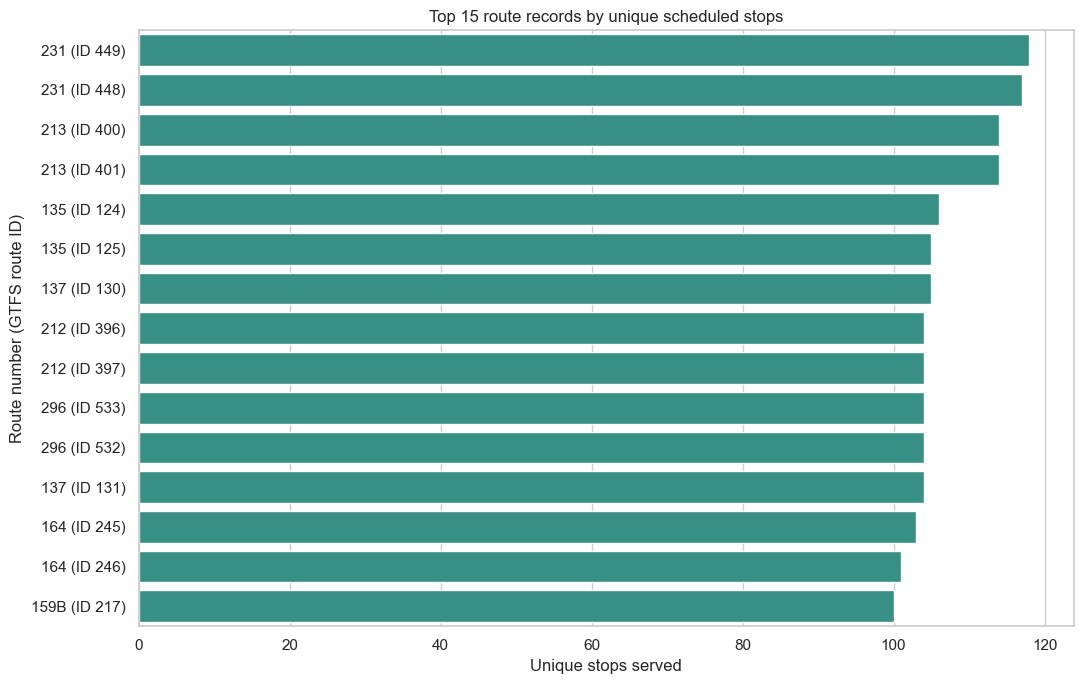

In [6]:
route_coverage = (
    analysis.groupby(['route_id', 'route_short_name'], dropna=False)
    .agg(unique_stops=('stop_id', 'nunique'), scheduled_trips=('trip_id', 'nunique'))
    .reset_index()
    .sort_values('unique_stops', ascending=False)
)
route_coverage['route_label'] = (
    route_coverage['route_short_name'].astype(str) + ' (ID ' + route_coverage['route_id'].astype(str) + ')'
)
top_coverage = route_coverage.head(15)
display(top_coverage[['route_id', 'route_short_name', 'unique_stops', 'scheduled_trips']])

plt.figure(figsize=(11, 7))
sns.barplot(data=top_coverage, x='unique_stops', y='route_label', color='#2a9d8f')
plt.title('Top 15 route records by unique scheduled stops')
plt.xlabel('Unique stops served')
plt.ylabel('Route number (GTFS route ID)')
plt.tight_layout()
plt.show()

**Interpretation:** This is timetable coverage—the number of distinct published stops on a route record. It does not show geographic distance, travel time, or the quality of access to those stops.

## 6. Scheduled headways

,minutes
count,"598,861.00"
mean,38.80
std,56.72
min,0.73
25%,15.00
50%,20.00
75%,35.00
90%,85.00
95%,140.00
max,"1,175.00"


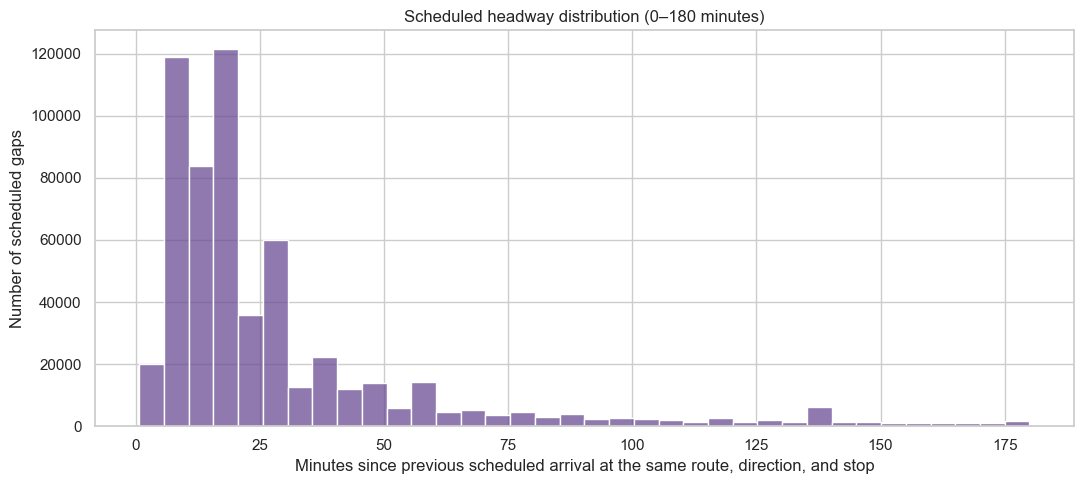

In [7]:
headways = analysis['headway_minutes'].dropna()
headway_summary = headways.describe(percentiles=[0.25, 0.50, 0.75, 0.90, 0.95]).rename('minutes').to_frame()
headway_summary.loc['share_over_120_minutes', 'minutes'] = (headways > 120).mean() * 100
display(headway_summary)

display_limit = 180
plt.figure(figsize=(11, 5))
sns.histplot(headways[headways <= display_limit], bins=36, color='#6a4c93')
plt.title(f'Scheduled headway distribution (0–{display_limit} minutes)')
plt.xlabel('Minutes since previous scheduled arrival at the same route, direction, and stop')
plt.ylabel('Number of scheduled gaps')
plt.tight_layout()
plt.show()

**Interpretation:** A headway is a planned timetable gap, not an observed passenger wait or a reliability measure. The chart limits the display to three hours so the common gaps remain readable; longer planned gaps still remain in the summary statistics.

## 7. Time-of-day analysis

,service_period,scheduled_stop_visits,share_percent
0,Early/Late,17069,2.72
1,Morning peak,105732,16.86
2,Midday,273678,43.63
3,Evening peak,128009,20.41
4,Night,102711,16.38


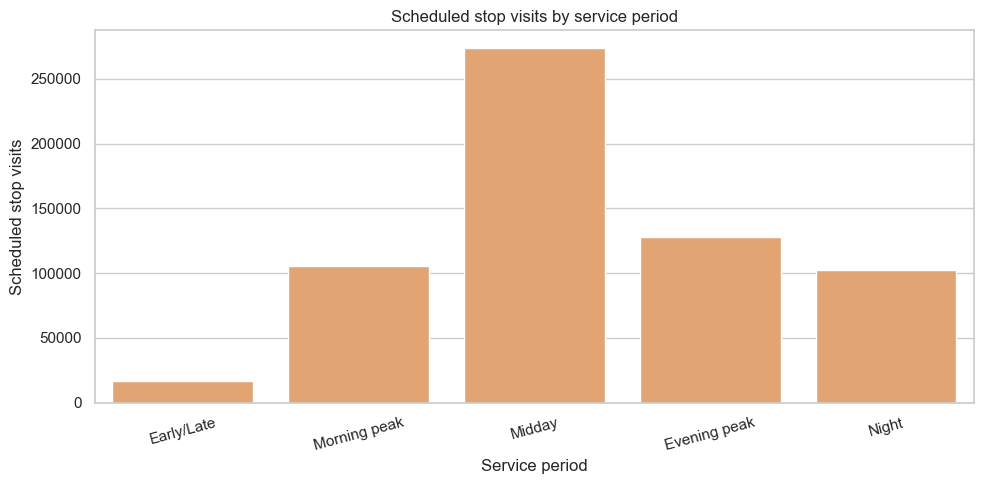

In [8]:
period_order = ['Early/Late', 'Morning peak', 'Midday', 'Evening peak', 'Night']
period_activity = (
    analysis['service_period'].value_counts()
    .reindex(period_order, fill_value=0)
    .rename_axis('service_period')
    .reset_index(name='scheduled_stop_visits')
)
period_activity['share_percent'] = period_activity['scheduled_stop_visits'] / len(analysis) * 100
display(period_activity)

plt.figure(figsize=(10, 5))
sns.barplot(data=period_activity, x='service_period', y='scheduled_stop_visits', color='#f4a261')
plt.title('Scheduled stop visits by service period')
plt.xlabel('Service period')
plt.ylabel('Scheduled stop visits')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

**Interpretation:** This distribution reflects the published timetable. It shows when scheduled activity is concentrated, but it cannot establish when passengers actually travel.

## 8. Overnight service

,metric,value
0,Overnight scheduled arrivals,4671
1,Share of scheduled stop visits,0.74%
2,Latest GTFS service-day arrival,27:05:16


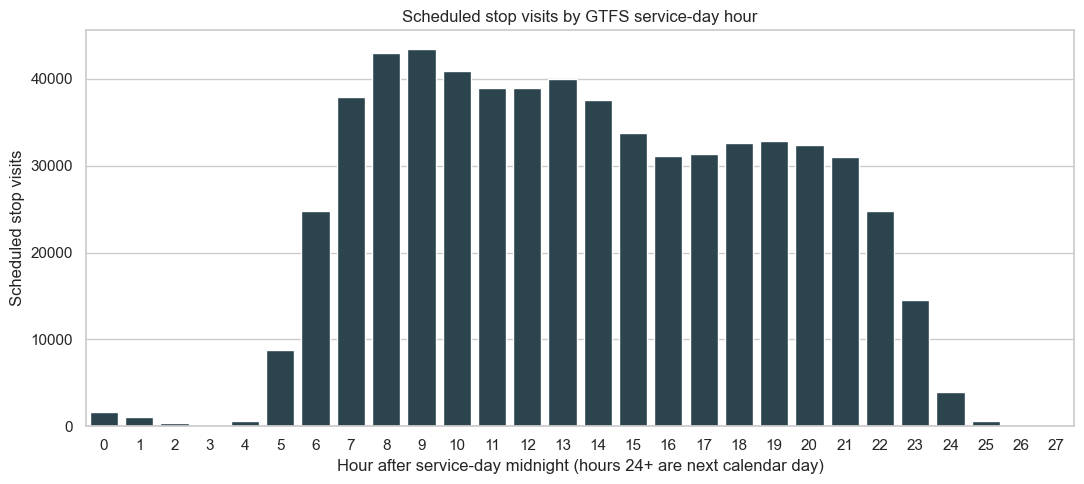

In [9]:
overnight = analysis[analysis['arrival_seconds'] >= 86400].copy()
latest_seconds = int(analysis['arrival_seconds'].max())
latest_time = f"{latest_seconds // 3600:02d}:{(latest_seconds % 3600) // 60:02d}:{latest_seconds % 60:02d}"
overnight_summary = pd.DataFrame({
    'metric': ['Overnight scheduled arrivals', 'Share of scheduled stop visits', 'Latest GTFS service-day arrival'],
    'value': [len(overnight), f"{len(overnight) / len(analysis) * 100:.2f}%", latest_time],
})
display(overnight_summary)

hourly_arrivals = (analysis.assign(service_hour=analysis['arrival_seconds'] // 3600)
                   .groupby('service_hour').size().reset_index(name='scheduled_stop_visits'))
plt.figure(figsize=(11, 5))
sns.barplot(data=hourly_arrivals, x='service_hour', y='scheduled_stop_visits', color='#264653')
plt.title('Scheduled stop visits by GTFS service-day hour')
plt.xlabel('Hour after service-day midnight (hours 24+ are next calendar day)')
plt.ylabel('Scheduled stop visits')
plt.tight_layout()
plt.show()

**Interpretation:** GTFS permits hours above 23 to keep post-midnight trips attached to the same service day. For example, `27:05:16` represents 3:05:16 AM on the next calendar day.

## 9. Geographic distribution of scheduled stops

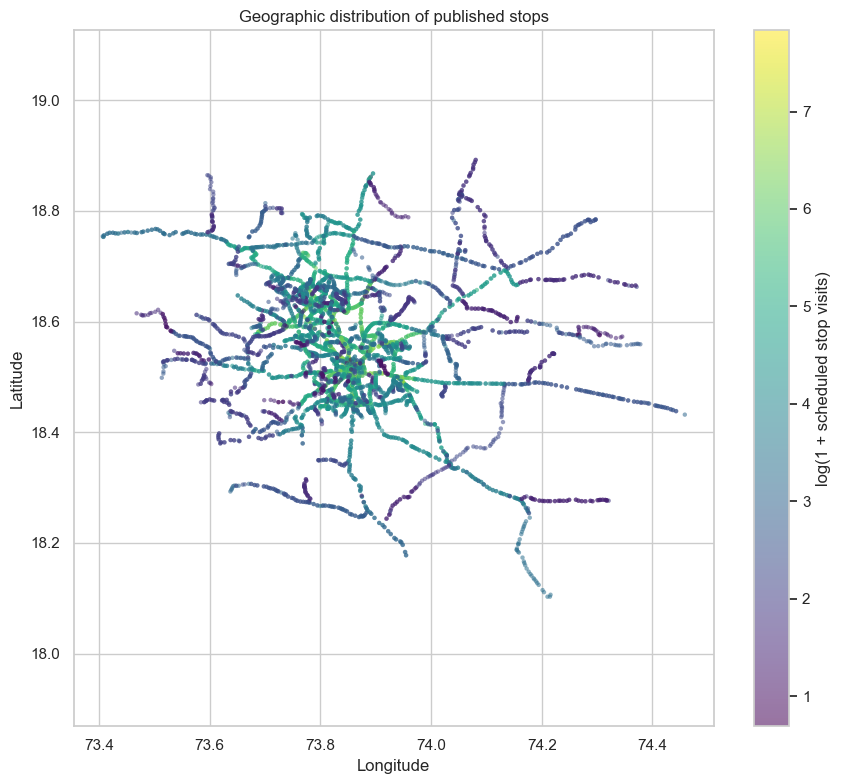

Latitude range: 18.102959 to 18.892073
Longitude range: 73.406998 to 74.458550


In [10]:
stop_map = stops.merge(
    stop_activity[['stop_id', 'scheduled_stop_visits']], on='stop_id', how='left'
).fillna({'scheduled_stop_visits': 0})

plt.figure(figsize=(9, 8))
scatter = plt.scatter(
    stop_map['stop_lon'], stop_map['stop_lat'],
    c=np.log1p(stop_map['scheduled_stop_visits']), cmap='viridis', s=10, alpha=0.55, linewidths=0
)
plt.colorbar(scatter, label='log(1 + scheduled stop visits)')
plt.title('Geographic distribution of published stops')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.axis('equal')
plt.tight_layout()
plt.show()

print(f"Latitude range: {stop_map['stop_lat'].min():.6f} to {stop_map['stop_lat'].max():.6f}")
print(f"Longitude range: {stop_map['stop_lon'].min():.6f} to {stop_map['stop_lon'].max():.6f}")

**Interpretation:** The map shows the geographic spread of published stop coordinates and relative scheduled activity. It is not a population-density, accessibility, or service-equity map because it does not include people, land use, road distance, or actual operations.

# Key Findings

- **Network scale:** The final cleaned feed contains **627 route records**, **6,696 stops**, **15,138 trips**, and **627,199 scheduled stop visits**—an average of **41.43 stop visits per trip**.
- **Highest scheduled activity:** Route number **149** has **13,753** scheduled stop visits across GTFS route IDs 178 and 179. Route number **159** has 10,170, and route number **43** has 9,527.
- **Potential interchange locations:** **Swargate** is served by **96** route records and has 2,519 scheduled visits. Pune Station Moledina Stand and St Colony are each served by 79 route records. These are candidates for further transfer-facility investigation.
- **Route coverage:** The route records for number **231** (IDs 449 and 448) cover 118 and 117 unique scheduled stops respectively. This is timetable coverage, not route length or quality of access.
- **Planned frequency:** The median scheduled headway is **20 minutes**. The middle 50% of planned gaps fall between **15 and 35 minutes**; the 90th percentile is **85 minutes**.
- **Service timing:** Midday contains **273,678** stop visits (43.6% of the schedule), followed by evening peak with 128,009.
- **Overnight timetable:** The feed includes **4,671** post-midnight arrivals. The latest published time is **27:05:16** in GTFS service-day notation.
- **Geography:** Published stops span latitude 18.102959–18.892073 and longitude 73.406998–74.458550, forming the mapped Pune-area schedule footprint.

These findings describe the **published schedule only**. To evaluate real-world reliability, waiting time, crowding, or passenger demand, future work needs GTFS-realtime/GPS data, actual arrival logs, ticketing data, or passenger surveys.